# H-CAST Soft-Topdown Grid Search

This notebook analyzes soft-topdown grid-search runs and selects the best config by **validation FPA top-down**.
Then it compares:
- best soft-topdown run,
- normal H-CAST,
- H-CAST Design1 (`temp10_withoutgk`).


In [9]:
from pathlib import Path
import csv
import json
import math
import re

import numpy as np
import yaml
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [10]:

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
ARTIFACT_DIR = None  # Optional override: Path('/scratch/g.saggini1/outputs/hcast_softtd_optuna_<tag>')
SEARCH_KIND = None   # Optional override: 'optuna' | 'gridsearch' | 'halving_gridsearch'

BASELINE_RUN_DIR = OUTPUTS_ROOT / 'hcast_cifar100_0.2mix'
DESIGN1_RUN_DIR = OUTPUTS_ROOT / 'hcast_design1_cifar100_temp10_withoutgk'

def detect_artifact_kind(path):
    path = Path(path)
    if (path / 'optuna_trials.csv').exists():
        return 'optuna'
    if (path / 'gridsearch_runs.csv').exists():
        return 'gridsearch'
    if (path / 'halving_gridsearch_runs.csv').exists():
        return 'halving_gridsearch'
    return None

def find_latest_artifact_dir(outputs_root):
    patterns = [
        'hcast_softtd_optuna_*',
        'hcast_softtd_gs_*',
        'hcast_softtd_hgs_*',
    ]
    candidates = []
    for pattern in patterns:
        for path in outputs_root.glob(pattern):
            if not path.is_dir():
                continue
            kind = detect_artifact_kind(path)
            if kind is None:
                continue
            candidates.append((path.stat().st_mtime, path, kind))
    if not candidates:
        return None, None
    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1], candidates[0][2]

if ARTIFACT_DIR is None:
    ARTIFACT_DIR, SEARCH_KIND = find_latest_artifact_dir(OUTPUTS_ROOT)
else:
    ARTIFACT_DIR = Path(ARTIFACT_DIR)
    SEARCH_KIND = SEARCH_KIND or detect_artifact_kind(ARTIFACT_DIR)

if ARTIFACT_DIR is None or SEARCH_KIND is None:
    raise ValueError(
        'No compatible soft-topdown artifact directory found. '        'Expected optuna/gridsearch/halving_gridsearch artifacts under /scratch/g.saggini1/outputs.'
    )

ARTIFACT_DIR = Path(ARTIFACT_DIR)
if SEARCH_KIND == 'optuna':
    RUNS_CSV = ARTIFACT_DIR / 'optuna_trials.csv'
    RESULTS_YAML = ARTIFACT_DIR / 'optuna_results.yaml'
    SPACE_YAML = ARTIFACT_DIR / 'optuna_search_space.yaml'
elif SEARCH_KIND == 'halving_gridsearch':
    RUNS_CSV = ARTIFACT_DIR / 'halving_gridsearch_runs.csv'
    RESULTS_YAML = ARTIFACT_DIR / 'halving_gridsearch_results.yaml'
    SPACE_YAML = ARTIFACT_DIR / 'halving_gridsearch_space.yaml'
else:
    RUNS_CSV = ARTIFACT_DIR / 'gridsearch_runs.csv'
    RESULTS_YAML = ARTIFACT_DIR / 'gridsearch_results.yaml'
    SPACE_YAML = ARTIFACT_DIR / 'gridsearch_space.yaml'

print(f'Using artifact dir: {ARTIFACT_DIR}')
print(f'  search kind : {SEARCH_KIND}')
print(f'  runs csv    : {RUNS_CSV}')
print(f'  results yaml: {RESULTS_YAML}')
print(f'  space yaml  : {SPACE_YAML}')


Using artifact dir: /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703
  search kind : optuna
  runs csv    : /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/optuna_trials.csv
  results yaml: /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/optuna_results.yaml
  space yaml  : /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/optuna_search_space.yaml


In [11]:
_ACC_LEVEL_PATTERN = re.compile(r'^acc_level_(\d+)$')
_ACC_LEVEL_TOPDOWN_PATTERN = re.compile(r'^acc_level_topdown_(\d+)$')
_ACC_LEVEL_INDEPENDENT_PATTERN = re.compile(r'^acc_level_independent_(\d+)$')

def load_yaml(path):
    path = Path(path)
    if not path.exists():
        return None
    with path.open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)

def load_jsonl_events(path):
    events = []
    path = Path(path)
    if not path.exists():
        return events
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                events.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return events

def _as_float_dict(metrics):
    out = {}
    if not isinstance(metrics, dict):
        return out
    for key, value in metrics.items():
        try:
            out[str(key)] = float(value)
        except (TypeError, ValueError):
            continue
    return out

def normalize_metrics(metrics):
    out = _as_float_dict(metrics)

    if 'weighted_ap_topdown' not in out:
        if 'weighted_ap' in out:
            out['weighted_ap_topdown'] = out['weighted_ap']
        elif 'weighted_ap_independent' in out:
            out['weighted_ap_topdown'] = out['weighted_ap_independent']
    if 'weighted_ap_independent' not in out and 'weighted_ap_topdown' in out:
        out['weighted_ap_independent'] = out['weighted_ap_topdown']

    if 'fpa_topdown' not in out:
        if 'fpa' in out:
            out['fpa_topdown'] = out['fpa']
        elif 'fpa_independent' in out:
            out['fpa_topdown'] = out['fpa_independent']
    if 'fpa_independent' not in out and 'fpa_topdown' in out:
        out['fpa_independent'] = out['fpa_topdown']

    if 'tice_topdown' not in out:
        if 'tice' in out:
            out['tice_topdown'] = out['tice']
        elif 'tice_independent' in out:
            out['tice_topdown'] = out['tice_independent']
    if 'tice_independent' not in out and 'tice_topdown' in out:
        out['tice_independent'] = out['tice_topdown']

    if 'ahd_topdown' not in out:
        if 'ahd' in out:
            out['ahd_topdown'] = out['ahd']
        elif 'ahd_independent' in out:
            out['ahd_topdown'] = out['ahd_independent']
    if 'ahd_independent' not in out and 'ahd_topdown' in out:
        out['ahd_independent'] = out['ahd_topdown']

    legacy_topdown = {}
    legacy_independent = {}
    for key, value in list(out.items()):
        mt = _ACC_LEVEL_TOPDOWN_PATTERN.match(key)
        if mt:
            legacy_topdown[int(mt.group(1))] = value
        mi = _ACC_LEVEL_INDEPENDENT_PATTERN.match(key)
        if mi:
            legacy_independent[int(mi.group(1))] = value

    for key, value in list(out.items()):
        m = _ACC_LEVEL_PATTERN.match(key)
        if not m:
            continue
        idx = int(m.group(1))
        legacy_topdown.setdefault(idx, value)

    for idx, value in legacy_topdown.items():
        out.setdefault(f'acc_level_topdown_{idx}', value)
    for idx, value in legacy_independent.items():
        out.setdefault(f'acc_level_independent_{idx}', value)

    return out

def metric_for_best(metrics):
    has_fpa = 'fpa_topdown' in metrics
    has_tice = 'tice_topdown' in metrics
    has_wap = 'weighted_ap_topdown' in metrics
    if has_fpa or has_tice or has_wap:
        fpa = float(metrics.get('fpa_topdown', 0.0))
        neg_tice = -float(metrics.get('tice_topdown', 1.0))
        wap = float(metrics.get('weighted_ap_topdown', 0.0))
        return float(fpa + 1e-3 * neg_tice + 1e-6 * wap)

    deepest_topdown = [
        k for k in metrics if k.startswith('acc_level_topdown_') and k[len('acc_level_topdown_'):].isdigit()
    ]
    deepest_independent = [
        k for k in metrics if k.startswith('acc_level_independent_') and k[len('acc_level_independent_'):].isdigit()
    ]
    deepest = deepest_topdown or deepest_independent
    if not deepest:
        return float(metrics.get('fpa_topdown', 0.0))

    deepest_key = max(deepest, key=lambda key: int(key.rsplit('_', 1)[-1]))
    primary = float(metrics.get(deepest_key, 0.0))
    tie = float(metrics.get('fpa_topdown', 0.0))
    return float(primary + 1e-3 * tie)

def parse_run(run_dir):
    run_path = Path(run_dir)
    events = load_jsonl_events(run_path / 'run_log.jsonl')

    epoch_events = []
    for event in events:
        if str(event.get('event', '')) != 'epoch':
            continue
        event = dict(event)
        event['val_metrics_norm'] = normalize_metrics(event.get('val_metrics', {}))
        event['rank_score'] = metric_for_best(event['val_metrics_norm'])
        epoch_events.append(event)

    best_epoch_event = None
    if epoch_events:
        best_idx = int(np.argmax([event['rank_score'] for event in epoch_events]))
        best_epoch_event = epoch_events[best_idx]

    test_blob = load_yaml(run_path / 'test_metrics.yaml') or {}
    test_metrics = normalize_metrics(test_blob.get('test_metrics', {}))

    cfg = load_yaml(run_path / 'config_resolved.yaml') or {}
    level_names = list((cfg.get('dataset') or {}).get('levels', []))

    return {
        'run_dir': run_path,
        'epoch_events': epoch_events,
        'best_epoch_event': best_epoch_event,
        'test_metrics': test_metrics,
        'level_names': level_names,
    }

def get_metric_series(epoch_events, metric_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event['val_metrics_norm'].get(metric_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


In [12]:

if not RUNS_CSV.exists():
    raise FileNotFoundError(f'Runs CSV not found: {RUNS_CSV}')

space_blob = load_yaml(SPACE_YAML) or {}
results_blob = load_yaml(RESULTS_YAML) or {}
sampled_values = (
    space_blob.get('sampled_values')
    or space_blob.get('sampled_values_for_grid')
    or {}
)
print(f'Search kind: {SEARCH_KIND}')
print('Sampled values:', sampled_values)

if SEARCH_KIND == 'optuna':
    expected_runs = int(space_blob.get('n_trials', space_blob.get('grid_num_combinations', 0)) or 0)
elif SEARCH_KIND == 'halving_gridsearch':
    expected_runs = int(space_blob.get('num_candidates_initial', 0) or 0)
else:
    expected_runs = int(space_blob.get('num_combinations', 0) or 0)

runs = []
rows_read = 0
with RUNS_CSV.open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows_read += 1
        row = dict(row)

        if SEARCH_KIND == 'optuna':
            row['idx'] = int(row.get('trial_number', rows_read))
            row['run_id'] = f"trial_{row['idx']}"
            row['state'] = str(row.get('state', '')).upper()
            row['gate_strength'] = float(row.get('gate_strength', np.nan))
            row['kl_weight'] = float(row.get('kl_weight', np.nan))
            row['tau'] = float(row.get('tau', np.nan))
        else:
            row['idx'] = int(row.get('idx', rows_read))
            row['run_id'] = str(row.get('run_id', row.get('candidate_id', f"run_{row['idx']}")))
            row['state'] = str(row.get('state', 'COMPLETE')).upper()
            row['gate_strength'] = float(row.get('gate_strength', np.nan))
            row['kl_weight'] = float(row.get('kl_weight', np.nan))
            row['tau'] = float(row.get('tau', np.nan))

        run_dir = row.get('run_dir', '')
        if not run_dir:
            row['parsed'] = {'epoch_events': [], 'best_epoch_event': None, 'test_metrics': {}, 'level_names': []}
            row['best_val_fpa_topdown'] = np.nan
            row['best_rank_score'] = np.nan
            row['best_epoch'] = None
            runs.append(row)
            continue

        parsed = parse_run(run_dir)
        row['parsed'] = parsed

        fpa_values = []
        for event in parsed['epoch_events']:
            value = float(event['val_metrics_norm'].get('fpa_topdown', np.nan))
            if np.isfinite(value):
                fpa_values.append(value)

        row['best_val_fpa_topdown'] = max(fpa_values) if fpa_values else np.nan
        row['best_rank_score'] = float(parsed['best_epoch_event']['rank_score']) if parsed['best_epoch_event'] else np.nan
        row['best_epoch'] = int(parsed['best_epoch_event']['epoch']) if parsed['best_epoch_event'] else None
        runs.append(row)

def _sort_key(run):
    fpa = run.get('best_val_fpa_topdown', np.nan)
    rank = run.get('best_rank_score', np.nan)
    fpa_sort = float(fpa) if np.isfinite(fpa) else -np.inf
    rank_sort = float(rank) if np.isfinite(rank) else -np.inf
    return (fpa_sort, rank_sort)

ranked_runs = sorted(runs, key=_sort_key, reverse=True)
best_soft_run = ranked_runs[0] if ranked_runs else None

print(f'Total CSV rows loaded: {rows_read}')
print(f'Total runs parsed    : {len(ranked_runs)}')
if expected_runs > 0 and rows_read != expected_runs:
    print(f'[warning] expected {expected_runs} runs from space file, found {rows_read} rows in CSV')

if best_soft_run is not None:
    print(
        'Best soft-topdown run: '
        f"id={best_soft_run['run_id']} fpa_td={best_soft_run['best_val_fpa_topdown']:.4f} "
        f"epoch={best_soft_run['best_epoch']} dir={best_soft_run['run_dir']}"
    )

artifact_best_path = (
    (results_blob.get('best_run') or {}).get('run_dir')
    or (results_blob.get('best_trial') or {}).get('run_dir')
    or results_blob.get('best_run_path')
)
if artifact_best_path and best_soft_run is not None:
    artifact_best = Path(artifact_best_path)
    notebook_best = Path(best_soft_run['run_dir'])
    if artifact_best != notebook_best:
        raise AssertionError(
            f'Best run mismatch: artifact={artifact_best} notebook={notebook_best}'
        )
    print(f'Best-run check passed against {RESULTS_YAML.name}: {artifact_best}')
elif not artifact_best_path:
    print(f'[info] {RESULTS_YAML.name} missing best-run field; skipping consistency assertion.')

print('\nTop-10 by best val fpa_topdown:')
print(f"{'rank':<6}{'id':<14}{'state':<10}{'fpa_td':<12}{'epoch':<8}{'g':<8}{'kl':<8}{'tau':<8}run_dir")
for rank, run in enumerate(ranked_runs[:10], start=1):
    fpa_txt = f"{run['best_val_fpa_topdown']:.4f}" if np.isfinite(run['best_val_fpa_topdown']) else 'n/a'
    epoch_txt = str(run['best_epoch']) if run['best_epoch'] is not None else 'n/a'
    print(
        f"{rank:<6}{str(run.get('run_id', run.get('idx', '?'))):<14}{str(run.get('state', '')):<10}{fpa_txt:<12}{epoch_txt:<8}"
        f"{run['gate_strength']:<8.4f}{run['kl_weight']:<8.4f}{run['tau']:<8.4f}{run.get('run_dir', '')}"
    )


Search kind: optuna
Sampled values: {'gate_strength': [0.3, 0.866667, 1.433333, 2.0], 'kl_weight': [0.05, 0.366667, 0.683333, 1.0], 'tau': [0.0, 0.133333, 0.266667, 0.4]}
Total CSV rows loaded: 64
Total runs parsed    : 64
Best soft-topdown run: id=trial_60 fpa_td=0.7280 epoch=97 dir=/scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/trials/trial_0060
Best-run check passed against optuna_results.yaml: /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/trials/trial_0060

Top-10 by best val fpa_topdown:
rank  id            state     fpa_td      epoch   g       kl      tau     run_dir
1     trial_60      COMPLETE  0.7280      97      0.3000  0.0500  0.0000  /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/trials/trial_0060
2     trial_59      COMPLETE  0.7269      96      0.3000  0.0500  0.4000  /scratch/g.saggini1/outputs/hcast_softtd_optuna_20260402_143703/trials/trial_0059
3     trial_21      COMPLETE  0.7266      95      0.3000  0.3667  0.4000 

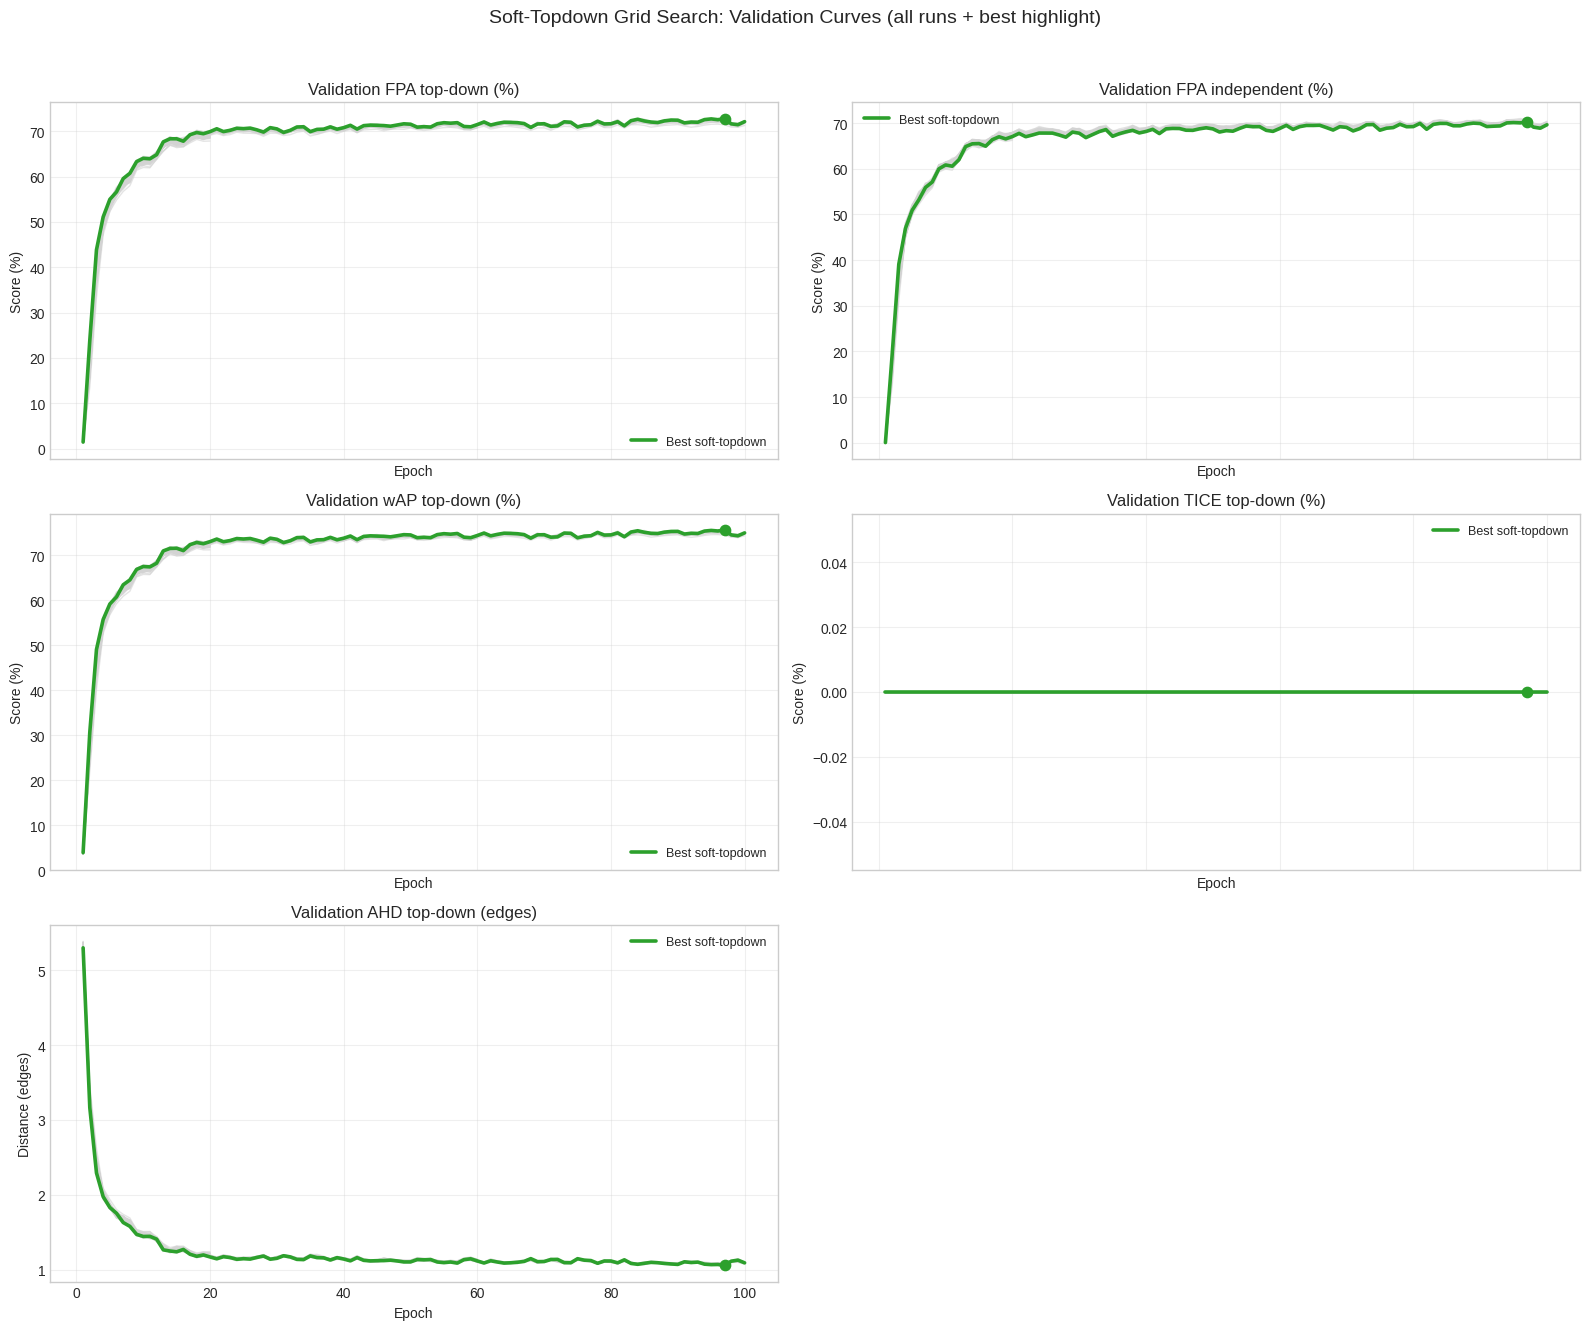

In [13]:
metric_specs = [
    ('fpa_topdown', 'Validation FPA top-down (%)', True),
    ('fpa_independent', 'Validation FPA independent (%)', True),
    ('weighted_ap_topdown', 'Validation wAP top-down (%)', True),
    ('tice_topdown', 'Validation TICE top-down (%)', True),
    ('ahd_topdown', 'Validation AHD top-down (edges)', False),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)
axes = axes.reshape(-1)

for ax, (metric_key, metric_title, is_percent) in zip(axes, metric_specs):
    for run in ranked_runs:
        epochs, values = get_metric_series(run['parsed']['epoch_events'], metric_key)
        if len(epochs) == 0:
            continue
        plot_values = values * 100.0 if is_percent else values
        ax.plot(epochs, plot_values, color='lightgray', linewidth=1.0, alpha=0.6)

    if best_soft_run is not None:
        epochs, values = get_metric_series(best_soft_run['parsed']['epoch_events'], metric_key)
        if len(epochs) > 0:
            plot_values = values * 100.0 if is_percent else values
            ax.plot(epochs, plot_values, color='#2ca02c', linewidth=2.6, label='Best soft-topdown')

            best_event = best_soft_run['parsed']['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter([best_event['epoch']], [best_plot_value], color='#2ca02c', marker='o', s=55, zorder=5)

    ax.set_title(metric_title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

for ax in axes[len(metric_specs):]:
    ax.axis('off')

plt.suptitle('Soft-Topdown Grid Search: Validation Curves (all runs + best highlight)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
if best_soft_run is None:
    raise ValueError('No valid soft-topdown run found.')

FINAL_RUN_SPECS = [
    {'label': 'H-CAST 0.2mix', 'run_dir': BASELINE_RUN_DIR, 'color': '#1f77b4'},
    {'label': 'H-CAST Design1 (T=10, noGK)', 'run_dir': DESIGN1_RUN_DIR, 'color': '#ff7f0e'},
    {'label': 'Best H-CAST Soft Topdown', 'run_dir': Path(best_soft_run['run_dir']), 'color': '#2ca02c'},
]

final_runs = []
for spec in FINAL_RUN_SPECS:
    run_dir = Path(spec['run_dir'])
    if not (run_dir / 'run_log.jsonl').exists():
        print(f"[skip missing] {spec['label']}: {run_dir}")
        continue
    parsed = parse_run(run_dir)
    parsed.update(spec)
    final_runs.append(parsed)

if len(final_runs) < 2:
    raise ValueError('Need at least two runs available for final comparison.')

for run in final_runs:
    best = run['best_epoch_event']
    fpa_td = float(best['val_metrics_norm'].get('fpa_topdown', np.nan)) if best is not None else np.nan
    print(f"{run['label']}: best_epoch={best['epoch'] if best else 'n/a'} val_fpa_td={100.0 * fpa_td:.2f}%")


H-CAST 0.2mix: best_epoch=98 val_fpa_td=75.46%
H-CAST Design1 (T=10, noGK): best_epoch=90 val_fpa_td=74.45%
Best H-CAST Soft Topdown: best_epoch=97 val_fpa_td=72.80%


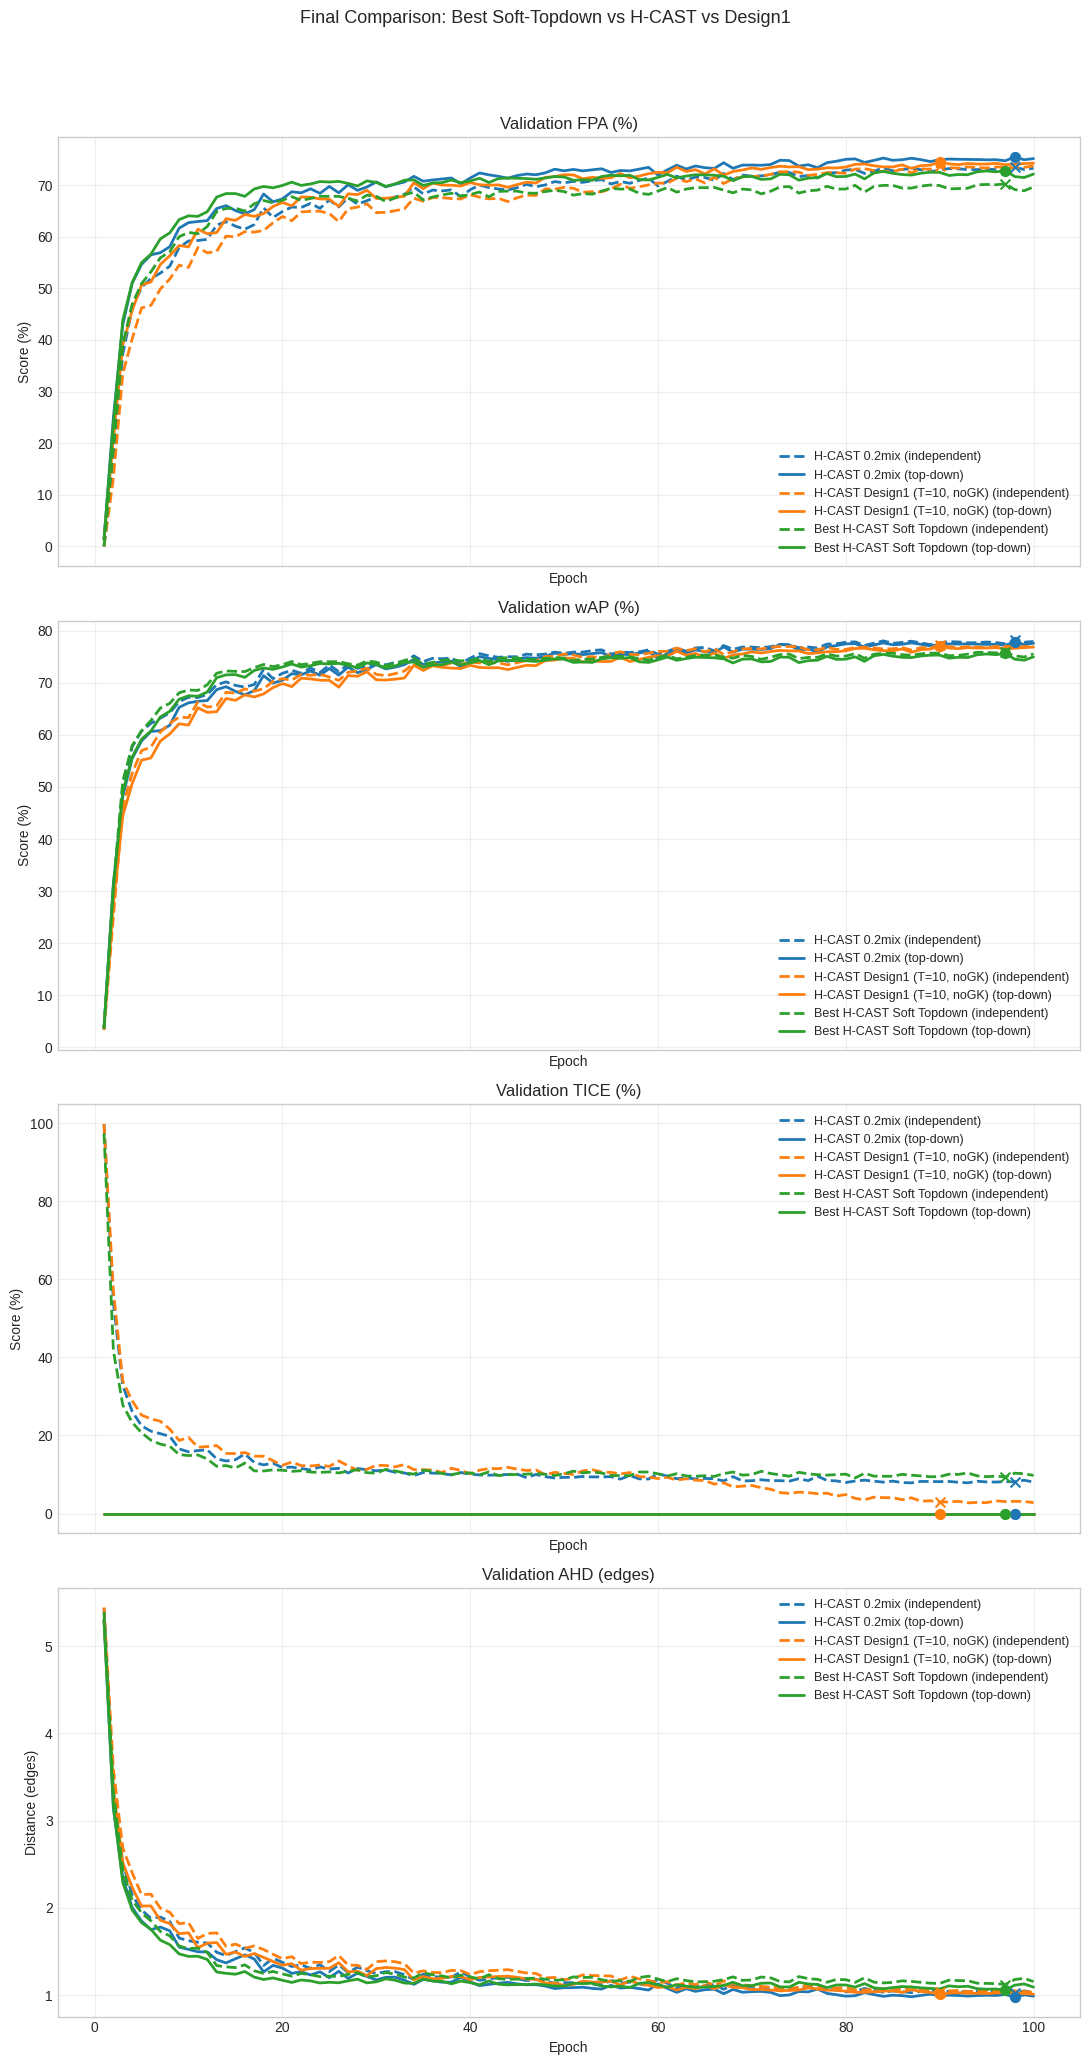

In [15]:
metric_families = [
    ('fpa', 'Validation FPA (%)', True),
    ('weighted_ap', 'Validation wAP (%)', True),
    ('tice', 'Validation TICE (%)', True),
    ('ahd', 'Validation AHD (edges)', False),
]
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

fig, axes = plt.subplots(len(metric_families), 1, figsize=(11, 5 * len(metric_families)), sharex=True)
if len(metric_families) == 1:
    axes = [axes]

for ax, (metric_prefix, metric_title, is_percent) in zip(axes, metric_families):
    for run in final_runs:
        for mode_key, line_style, mode_label, marker in mode_specs:
            metric_key = f'{metric_prefix}_{mode_key}'
            epochs, values = get_metric_series(run['epoch_events'], metric_key)
            if len(epochs) == 0:
                continue
            plot_values = values * 100.0 if is_percent else values
            ax.plot(
                epochs,
                plot_values,
                label=f"{run['label']} ({mode_label})",
                color=run['color'],
                linestyle=line_style,
                linewidth=2.0,
            )

            best_event = run['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter([best_event['epoch']], [best_plot_value], color=run['color'], marker=marker, s=50, zorder=4)

    ax.set_title(metric_title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Final Comparison: Best Soft-Topdown vs H-CAST vs Design1', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
if not final_runs:
    raise ValueError('No runs loaded for final comparison.')

base = final_runs[0]
comparisons = final_runs[1:]

metric_rows = [
    ('fpa_independent', 'FPA independent'),
    ('fpa_topdown', 'FPA top-down'),
    ('weighted_ap_independent', 'wAP independent'),
    ('weighted_ap_topdown', 'wAP top-down'),
    ('tice_independent', 'TICE independent'),
    ('tice_topdown', 'TICE top-down'),
    ('ahd_independent', 'AHD independent'),
    ('ahd_topdown', 'AHD top-down'),
]

def fmt_pct(x):
    return f'{100.0 * float(x):.2f}%' if np.isfinite(x) else 'n/a'

def fmt_edges(x):
    return f'{float(x):.3f}' if np.isfinite(x) else 'n/a'

def fmt_delta_pp(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{100.0 * x:+.2f} pp'

def fmt_delta_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{x:+.3f}'

header = f"{'Metric':<40}{base['label']:>20}"
for comp in comparisons:
    header += f"{comp['label']:>26}{'Delta vs base':>18}"
print(header)
print('-' * len(header))

for metric_key, metric_name in metric_rows:
    base_value = float(base['test_metrics'].get(metric_key, np.nan))
    is_distance = metric_key.startswith('ahd_')
    base_fmt = fmt_edges(base_value) if is_distance else fmt_pct(base_value)
    row = f"{metric_name:<40}{base_fmt:>20}"

    for comp in comparisons:
        comp_value = float(comp['test_metrics'].get(metric_key, np.nan))
        delta = comp_value - base_value if np.isfinite(base_value) and np.isfinite(comp_value) else np.nan
        comp_fmt = fmt_edges(comp_value) if is_distance else fmt_pct(comp_value)
        delta_fmt = fmt_delta_edges(delta) if is_distance else fmt_delta_pp(delta)
        row += f"{comp_fmt:>26}{delta_fmt:>18}"

    print(row)

best_fpa_td = float(best_soft_run['best_val_fpa_topdown']) if best_soft_run is not None else np.nan
if np.isfinite(best_fpa_td):
    print('\nSelected best soft-topdown by validation FPA top-down:')
    print(
        f"run_dir={best_soft_run['run_dir']} | g={best_soft_run['gate_strength']:.4f} "
        f"kl={best_soft_run['kl_weight']:.4f} tau={best_soft_run['tau']:.4f} "
        f"best_val_fpa_td={100.0 * best_fpa_td:.2f}%"
    )


Metric                                         H-CAST 0.2mixH-CAST Design1 (T=10, noGK)     Delta vs base  Best H-CAST Soft Topdown     Delta vs base
-----------------------------------------------------------------------------------------------------------------------------------------------------
FPA independent                                       72.56%                    73.00%          +0.44 pp                    70.12%          -2.44 pp
FPA top-down                                          74.28%                    73.64%          -0.63 pp                    72.22%          -2.06 pp
wAP independent                                       77.48%                    76.69%          -0.79 pp                    75.89%          -1.59 pp
wAP top-down                                          76.94%                    76.29%          -0.65 pp                    75.10%          -1.83 pp
TICE independent                                       8.12%                     3.17%          -4.94 pp